# Setup

In [1]:
from pathlib import Path
import os
import torch
import gymnasium as gym
import ale_py
import pandas as pd

from stable_baselines3 import A2C, DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.evaluation import evaluate_policy

# Register Atari/ALE environments like ALE/Pong-v5
gym.register_envs(ale_py)

# Find project root
cwd = Path.cwd()

if (cwd / "models").exists() and (cwd / "videos").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists() and (cwd.parent / "videos").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
VIDEO_DIR = PROJECT_ROOT / "videos"

MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
VIDEO_DIR.mkdir(exist_ok=True)

ENV_ID = "ALE/Pong-v5"
SEED = 0
N_EVAL_EPISODES = 5

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_CLASSES = {
    "A2C": A2C,
    "DQN": DQN,
}

print("Current working directory:", cwd)
print("Project root:", PROJECT_ROOT)
print("Model directory:", MODEL_DIR)
print("Results directory:", RESULTS_DIR)
print("Environment:", ENV_ID)
print("Evaluation episodes:", N_EVAL_EPISODES)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Current working directory: c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\code
Project root: c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3
Model directory: c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\models
Results directory: c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\results
Environment: ALE/Pong-v5
Evaluation episodes: 5
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
# for testing
N_EVAL_EPISODES = 10

# Check what model files exist

In [3]:
all_models = sorted(MODEL_DIR.glob("*.zip"))

print("Available model checkpoints:")

for model_file in all_models:
    print(model_file.name)

Available model checkpoints:


# Choose models to evaluate

In [4]:
models_to_evaluate = [
    # -------------------------
    # A2C checkpoints
    # -------------------------
    # ----------------------------------------------------
    # A2C v1: old/simple A2C experiment
    # ----------------------------------------------------
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 10_000,
        "filename": "a2c-v1/a2c_pong_10000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 20_000,
        "filename": "a2c-v1/a2c_pong_20000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 30_000,
        "filename": "a2c-v1/a2c_pong_30000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 40_000,
        "filename": "a2c-v1/a2c_pong_40000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 50_000,
        "filename": "a2c-v1/a2c_pong_50000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 150_000,
        "filename": "a2c-v1/a2c_pong_150000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 250_000,
        "filename": "a2c-v1/a2c_pong_250000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 350_000,
        "filename": "a2c-v1/a2c_pong_350000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 500_000,
        "filename": "a2c-v1/a2c_pong_500000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 1_000_000,
        "filename": "a2c-v1/a2c_pong_1000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v1",
        "timesteps": 2_000_000,
        "filename": "a2c-v1/a2c_pong_2000000.zip",
    },
    # ----------------------------------------------------
    # A2C v2: current/new A2C experiment
    # You can change this to 5_000_000 later.
    # ----------------------------------------------------
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 10_000,
        "filename": "a2c-v2/a2c_pong_10000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 20_000,
        "filename": "a2c-v2/a2c_pong_20000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 30_000,
        "filename": "a2c-v2/a2c_pong_30000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 40_000,
        "filename": "a2c-v2/a2c_pong_40000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 50_000,
        "filename": "a2c-v2/a2c_pong_50000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 150_000,
        "filename": "a2c-v2/a2c_pong_150000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 250_000,
        "filename": "a2c-v2/a2c_pong_250000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 350_000,
        "filename": "a2c-v2/a2c_pong_350000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 500_000,
        "filename": "a2c-v2/a2c_pong_500000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 1_000_000,
        "filename": "a2c-v2/a2c_pong_1000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 1_500_000,
        "filename": "a2c-v2/a2c_pong_1500000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 2_000_000,
        "filename": "a2c-v2/a2c_pong_2000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 3_000_000,
        "filename": "a2c-v2/a2c_pong_3000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 4_000_000,
        "filename": "a2c-v2/a2c_pong_4000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v2",
        "timesteps": 5_000_000,
        "filename": "a2c-v2/a2c_pong_5000000.zip",
    },
    # ----------------------------------------------------
    # A2C v3: current/new A2C experiment
    # ----------------------------------------------------
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 10_000,
        "filename": "a2c-v3/a2c_pong_10000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 20_000,
        "filename": "a2c-v3/a2c_pong_20000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 30_000,
        "filename": "a2c-v3/a2c_pong_30000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 40_000,
        "filename": "a2c-v3/a2c_pong_40000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 50_000,
        "filename": "a2c-v3/a2c_pong_50000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 150_000,
        "filename": "a2c-v3/a2c_pong_150000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 250_000,
        "filename": "a2c-v3/a2c_pong_250000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 350_000,
        "filename": "a2c-v3/a2c_pong_350000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 500_000,
        "filename": "a2c-v3/a2c_pong_500000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 1_000_000,
        "filename": "a2c-v3/a2c_pong_1000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 1_500_000,
        "filename": "a2c-v3/a2c_pong_1500000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 2_000_000,
        "filename": "a2c-v3/a2c_pong_2000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 3_000_000,
        "filename": "a2c-v3/a2c_pong_3000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 4_000_000,
        "filename": "a2c-v3/a2c_pong_4000000.zip",
    },
    {
        "algorithm": "A2C",
        "variant": "a2c-v3",
        "timesteps": 5_000_000,
        "filename": "a2c-v3/a2c_pong_5000000.zip",
    },
    # -------------------------
    # DQN checkpoints
    # -------------------------
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 10_000,
        "filename": "dqn-v1/dqn_pong_10000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 20_000,
        "filename": "dqn-v1/dqn_pong_20000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 30_000,
        "filename": "dqn-v1/dqn_pong_30000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 40_000,
        "filename": "dqn-v1/dqn_pong_40000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 50_000,
        "filename": "dqn-v1/dqn_pong_50000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 150_000,
        "filename": "dqn-v1/dqn_pong_150000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 250_000,
        "filename": "dqn-v1/dqn_pong_250000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 350_000,
        "filename": "dqn-v1/dqn_pong_350000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 500_000,
        "filename": "dqn-v1/dqn_pong_500000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 1_500_000,
        "filename": "dqn-v1/dqn_pong_1500000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 2_000_000,
        "filename": "dqn-v1/dqn_pong_2000000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 3_000_000,
        "filename": "dqn-v1/dqn_pong_3000000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 4_000_000,
        "filename": "dqn-v1/dqn_pong_4000000.zip",
    },
    {
        "algorithm": "DQN",
        "variant": "dqn-v1",
        "timesteps": 5_000_000,
        "filename": "dqn-v1/dqn_pong_5000000.zip",
    },
]

# Check which selected files exist

In [5]:
valid_models = []

for item in models_to_evaluate:
    model_path = MODEL_DIR / item["filename"]
    
    if model_path.exists():
        item = item.copy()
        item["model_path"] = model_path
        valid_models.append(item)
        print("Found:", item["variant"], "->", model_path)
    else:
        print("Missing:", item["variant"], "->", model_path)

print()
print("Models ready for evaluation:", len(valid_models))

Found: a2c-v1 -> c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\models\a2c-v1\a2c_pong_10000.zip
Found: a2c-v1 -> c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\models\a2c-v1\a2c_pong_20000.zip
Found: a2c-v1 -> c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\models\a2c-v1\a2c_pong_30000.zip
Found: a2c-v1 -> c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\models\a2c-v1\a2c_pong_40000.zip
Found: a2c-v1 -> c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\models\a2c-v1\a2c_pong_50000.zip
Found: a2c-v1 -> c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\models\a2c-v1\a2c_pong_150000.zip
Found: a2c-v1 -> c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\models\a2c-v1\a2c_pong_250000.zip
Found: a2c-v1 -> c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3

# create evaluation environment

In [6]:
def make_eval_env():
    """
    Create the same kind of Atari preprocessing environment used during training.
    Evaluation uses one environment for easier interpretation.
    """
    eval_env = make_atari_env(
        ENV_ID,
        n_envs=1,
        seed=SEED,
        wrapper_kwargs=dict(terminal_on_life_loss=False),
    )
    
    eval_env = VecFrameStack(eval_env, n_stack=4)
    
    return eval_env

# Evaluate all selected models

In [7]:
results = []

for item in valid_models:
    algorithm = item["algorithm"]
    timesteps = item["timesteps"]
    model_path = item["model_path"]
    
    ModelClass = MODEL_CLASSES[algorithm]
    
    print("=" * 70)
    print(f"Evaluating {algorithm} checkpoint")
    print(f"Model: {model_path.name}")
    print(f"Timesteps: {timesteps:,}")
    print("=" * 70)
    
    eval_env = make_eval_env()
    
    model = ModelClass.load(
        model_path,
        env=eval_env,
        device=device
    )
    
    mean_reward, std_reward = evaluate_policy(
        model,
        eval_env,
        n_eval_episodes=N_EVAL_EPISODES,
        deterministic=True,
        render=False
    )
    
    eval_env.close()
    
    result = {
        "algorithm": algorithm,
        "variant": item["variant"],
        "environment": ENV_ID,
        "checkpoint_file": model_path.name,
        "filename": item["filename"],
        "timesteps": timesteps,
        "n_eval_episodes": N_EVAL_EPISODES,
        "mean_reward": mean_reward,
        "std_reward": std_reward,
    }
    
    results.append(result)
    
    print(f"Mean reward: {mean_reward:.2f}")
    print(f"Std reward:  {std_reward:.2f}")
    print()

print("Evaluation complete.")

Evaluating A2C checkpoint
Model: a2c_pong_10000.zip
Timesteps: 10,000
Wrapping the env in a VecTransposeImage.
Mean reward: -21.00
Std reward:  0.00

Evaluating A2C checkpoint
Model: a2c_pong_20000.zip
Timesteps: 20,000
Wrapping the env in a VecTransposeImage.
Mean reward: -21.00
Std reward:  0.00

Evaluating A2C checkpoint
Model: a2c_pong_30000.zip
Timesteps: 30,000
Wrapping the env in a VecTransposeImage.
Mean reward: -21.00
Std reward:  0.00

Evaluating A2C checkpoint
Model: a2c_pong_40000.zip
Timesteps: 40,000
Wrapping the env in a VecTransposeImage.
Mean reward: -21.00
Std reward:  0.00

Evaluating A2C checkpoint
Model: a2c_pong_50000.zip
Timesteps: 50,000
Wrapping the env in a VecTransposeImage.
Mean reward: -21.00
Std reward:  0.00

Evaluating A2C checkpoint
Model: a2c_pong_150000.zip
Timesteps: 150,000
Wrapping the env in a VecTransposeImage.
Mean reward: -21.00
Std reward:  0.00

Evaluating A2C checkpoint
Model: a2c_pong_250000.zip
Timesteps: 250,000
Wrapping the env in a VecT

# Results table

In [8]:
results_df = pd.DataFrame(results)

results_df

,algorithm,variant,environment,checkpoint_file,filename,timesteps,n_eval_episodes,mean_reward,std_reward
0,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_10000.zip,a2c-v1/a2c_pong_10000.zip,10000,10,-21.0,0.000000
1,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_20000.zip,a2c-v1/a2c_pong_20000.zip,20000,10,-21.0,0.000000
2,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_30000.zip,a2c-v1/a2c_pong_30000.zip,30000,10,-21.0,0.000000
3,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_40000.zip,a2c-v1/a2c_pong_40000.zip,40000,10,-21.0,0.000000
4,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_50000.zip,a2c-v1/a2c_pong_50000.zip,50000,10,-21.0,0.000000
5,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_150000.zip,a2c-v1/a2c_pong_150000.zip,150000,10,-21.0,0.000000
6,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_250000.zip,a2c-v1/a2c_pong_250000.zip,250000,10,-21.0,0.000000
7,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_350000.zip,a2c-v1/a2c_pong_350000.zip,350000,10,-21.0,0.000000
8,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_500000.zip,a2c-v1/a2c_pong_500000.zip,500000,10,-21.0,0.000000
9,A2C,a2c-v1,ALE/Pong-v5,a2c_pong_1000000.zip,a2c-v1/a2c_pong_1000000.zip,1000000,10,-21.0,0.000000


# Save results to CSV

In [9]:
results_path = RESULTS_DIR / "pong_model_evaluation_results.csv"

results_df.to_csv(results_path, index=False)

print("Saved evaluation results to:", results_path)

Saved evaluation results to: c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\results\pong_model_evaluation_results.csv


# Plot results

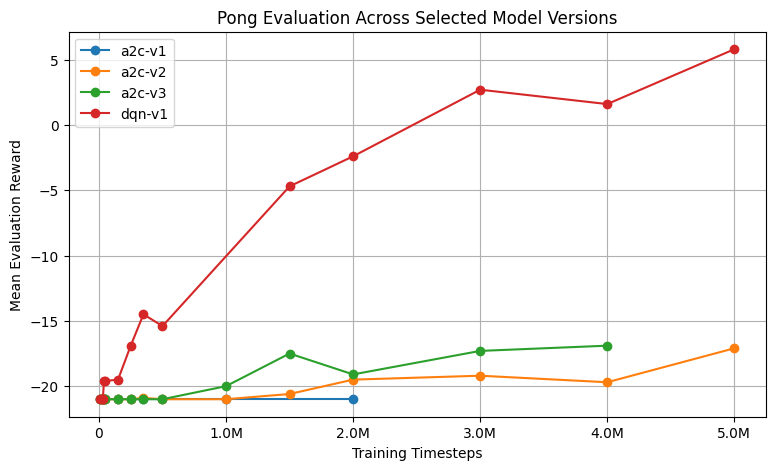

Saved plot to: c:\Users\dosan\Desktop\GradLevel\2-Spring 2026\CS264\Projects\StableBaselines3\results\pong_selected_model_versions_evaluation_plot.png


In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(9, 5))

for variant in results_df["variant"].unique():
    subset = results_df[results_df["variant"] == variant]
    subset = subset.sort_values("timesteps")
    
    plt.plot(
        subset["timesteps"],
        subset["mean_reward"],
        marker="o",
        label=variant
    )

def format_steps(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.0f}k"
    return str(int(x))

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_steps))

plt.xlabel("Training Timesteps")
plt.ylabel("Mean Evaluation Reward")
plt.title("Pong Evaluation Across Selected Model Versions")
plt.legend()
plt.grid(True)

plot_path = RESULTS_DIR / "pong_selected_model_versions_evaluation_plot.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved plot to:", plot_path)